# Basic Stats 1

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# Display the first few rows to confirm successful loading
display(df.head())

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


# Descriptive Analysis for Numerical Columns

In [ ]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns Identified:", list(numerical_cols))

# Calculate Mean, Median (50%), and Standard Deviation using describe()
desc_stats = df[numerical_cols].describe().T[['mean', '50%', 'std']]
desc_stats.rename(columns={'50%': 'median'}, inplace=True)

# Calculate Mode separately (as variables can have multiple modes, we take the first one)
modes = df[numerical_cols].mode().iloc[0]
desc_stats['mode'] = modes

print("\n--- Basic Statistical Measures ---")
display(desc_stats)

Numerical Columns Identified: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

--- Basic Statistical Measures ---


,mean,median,std,mode
Volume,5.066667,4.000000,4.231602,3.000000
Avg Price,10453.433333,1450.000000,18079.904840,400.000000
Total Sales Value,33812.835556,5700.000000,50535.074173,24300.000000
Discount Rate (%),15.155242,16.577766,4.220602,5.007822
Discount Amount,3346.499424,988.933733,4509.902963,69.177942
Net Sales Value,30466.336131,4677.788059,46358.656624,326.974801


# Interpretation & Descriptive Statistics

* **Mean & Median:** Comparing the mean and median for columns like `Total Sales`, `Avg Price`, and `Net Sales Value` helps us understand the central tendency. As the mean is significantly higher than the median, it indicates a right-skewed distribution (driven by a very high-value sales).
* **Mode:** The mode shows the most frequently occurring values.
* **Standard Deviation:** This measures the dispersion of the data. A high standard deviation in `Net Sales Value` suggests wide variability in how much revenue each transaction generates, highlighting a diverse product mix ranging from low-cost FMCG items to high-cost Mobiles.

# Data Visualization

## Histograms

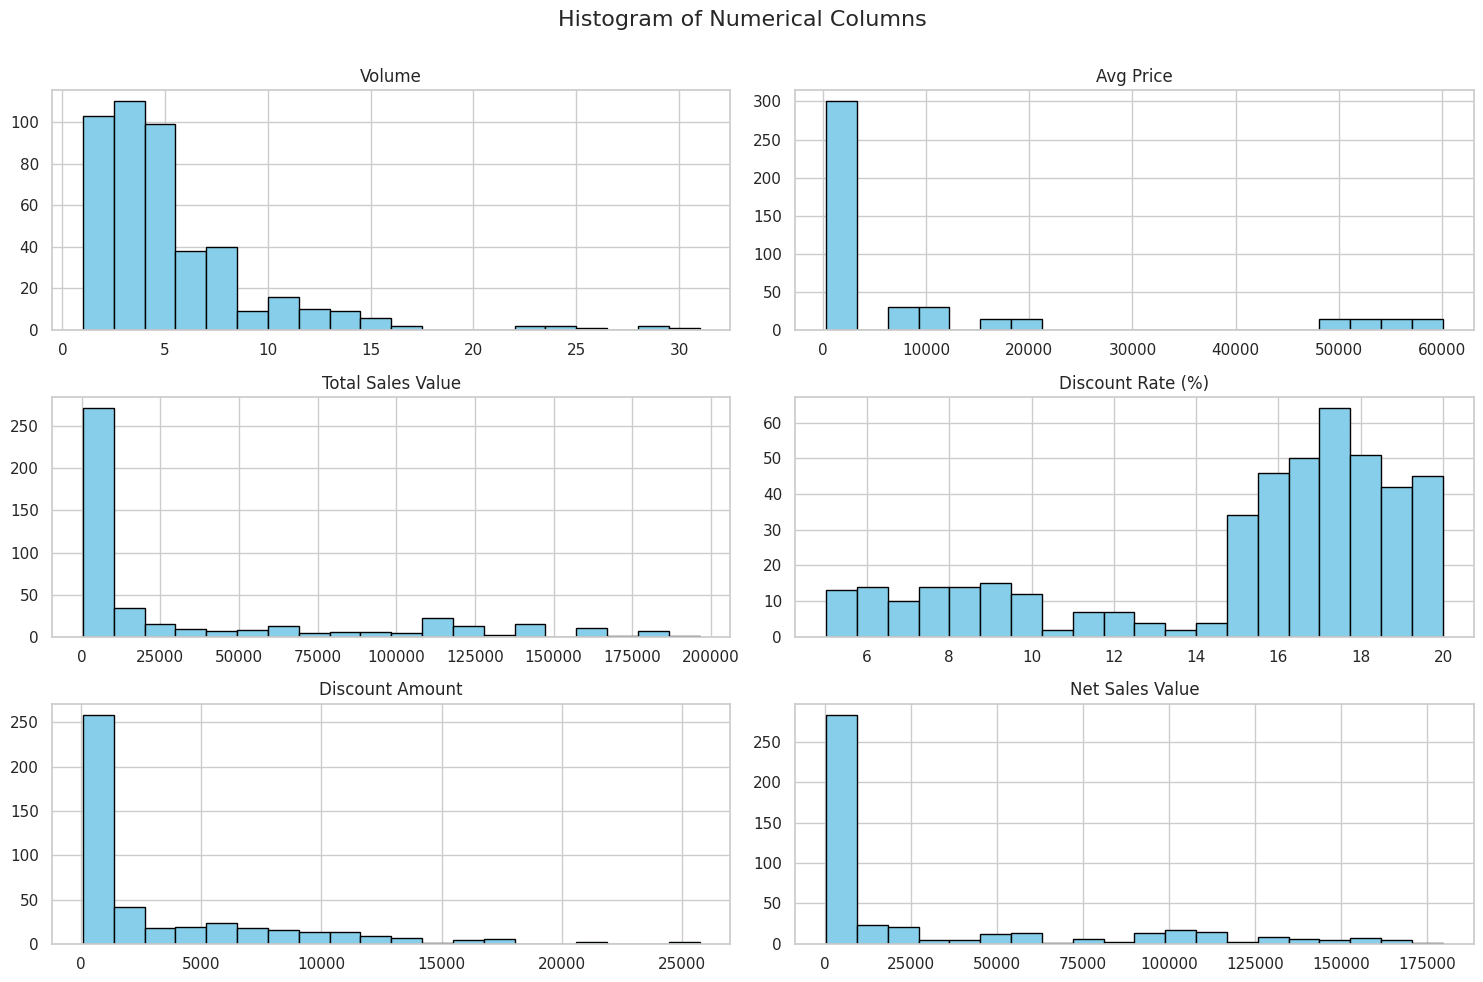

In [ ]:
df[numerical_cols].hist(bins=20,figsize=(15,10),color="skyblue",edgecolor="black")
plt.suptitle("Histogram of Numerical Columns",fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### Histogram Inferences
* **Skewness:** Most financial metrics like `Volume`, `Total Sales`, and `Net Sales Value` typically exhibit a right-skewed distribution. This means the majority of transactions are of lower value/volume, with a few exceptionally large transactions trailing off to the right.
* **Discounts:** The distribution of `Discount R` (Discount Rate) shows how discounts are typically clustered (e.g., around 10-15%), while `Discount A` (Discount Amount) likely mirrors the skewness of the total sales.

## Box Plots

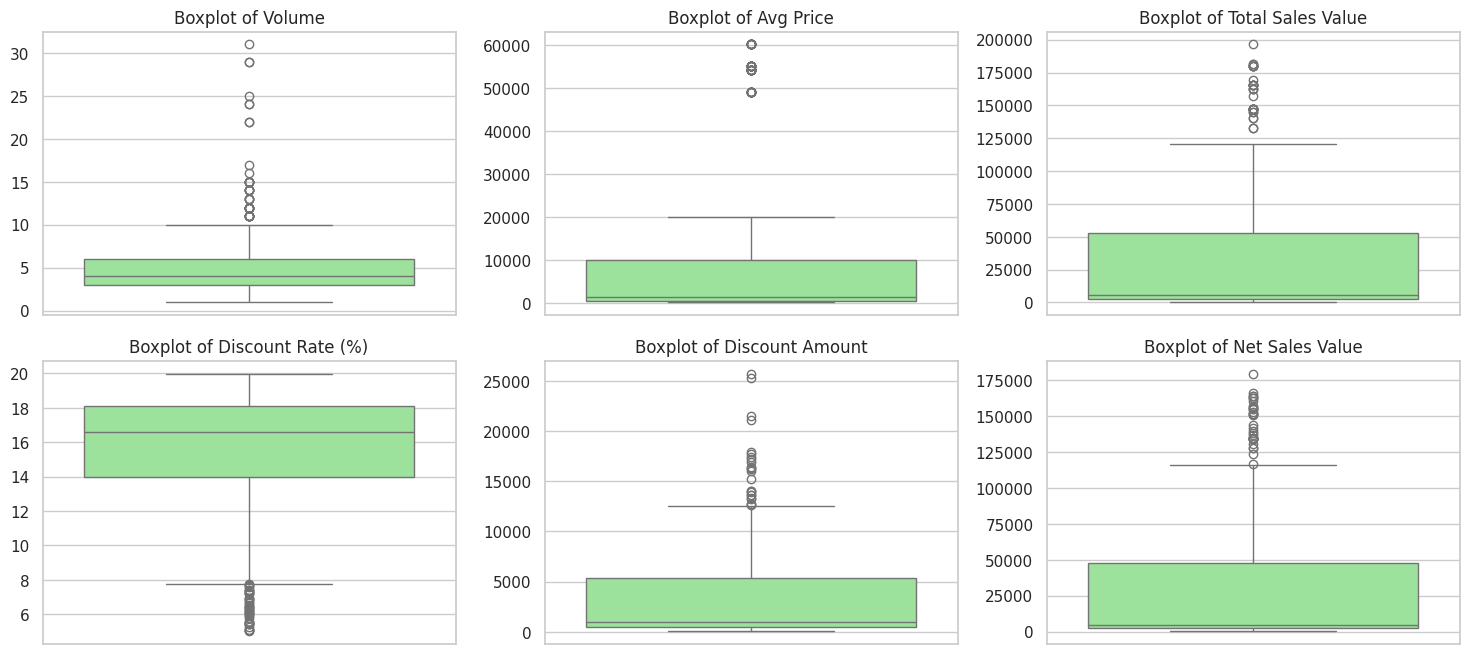

In [ ]:
# Boxplots for numerical variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Box Plot Inferences
* **Outliers:** The dots located outside the "whiskers" of the box plots represent outliers. Columns like `Total Sales` and `Net Sales Value` `Discount Amount` are expected to have significant upper outliers due to premium products (like high-end 'Mobiles' or bulk purchases).
* **Spread:** The size of the box (Interquartile Range) shows where 50% of the middle data lies. A compact box indicates tight clustering of data points around the median.

## Bar Chart Analysis for Categorical Columns

/tmp/ipykernel_3140/1026809413.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_3140/1026809413.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_3140/1026809413.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_3140/1026809413.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

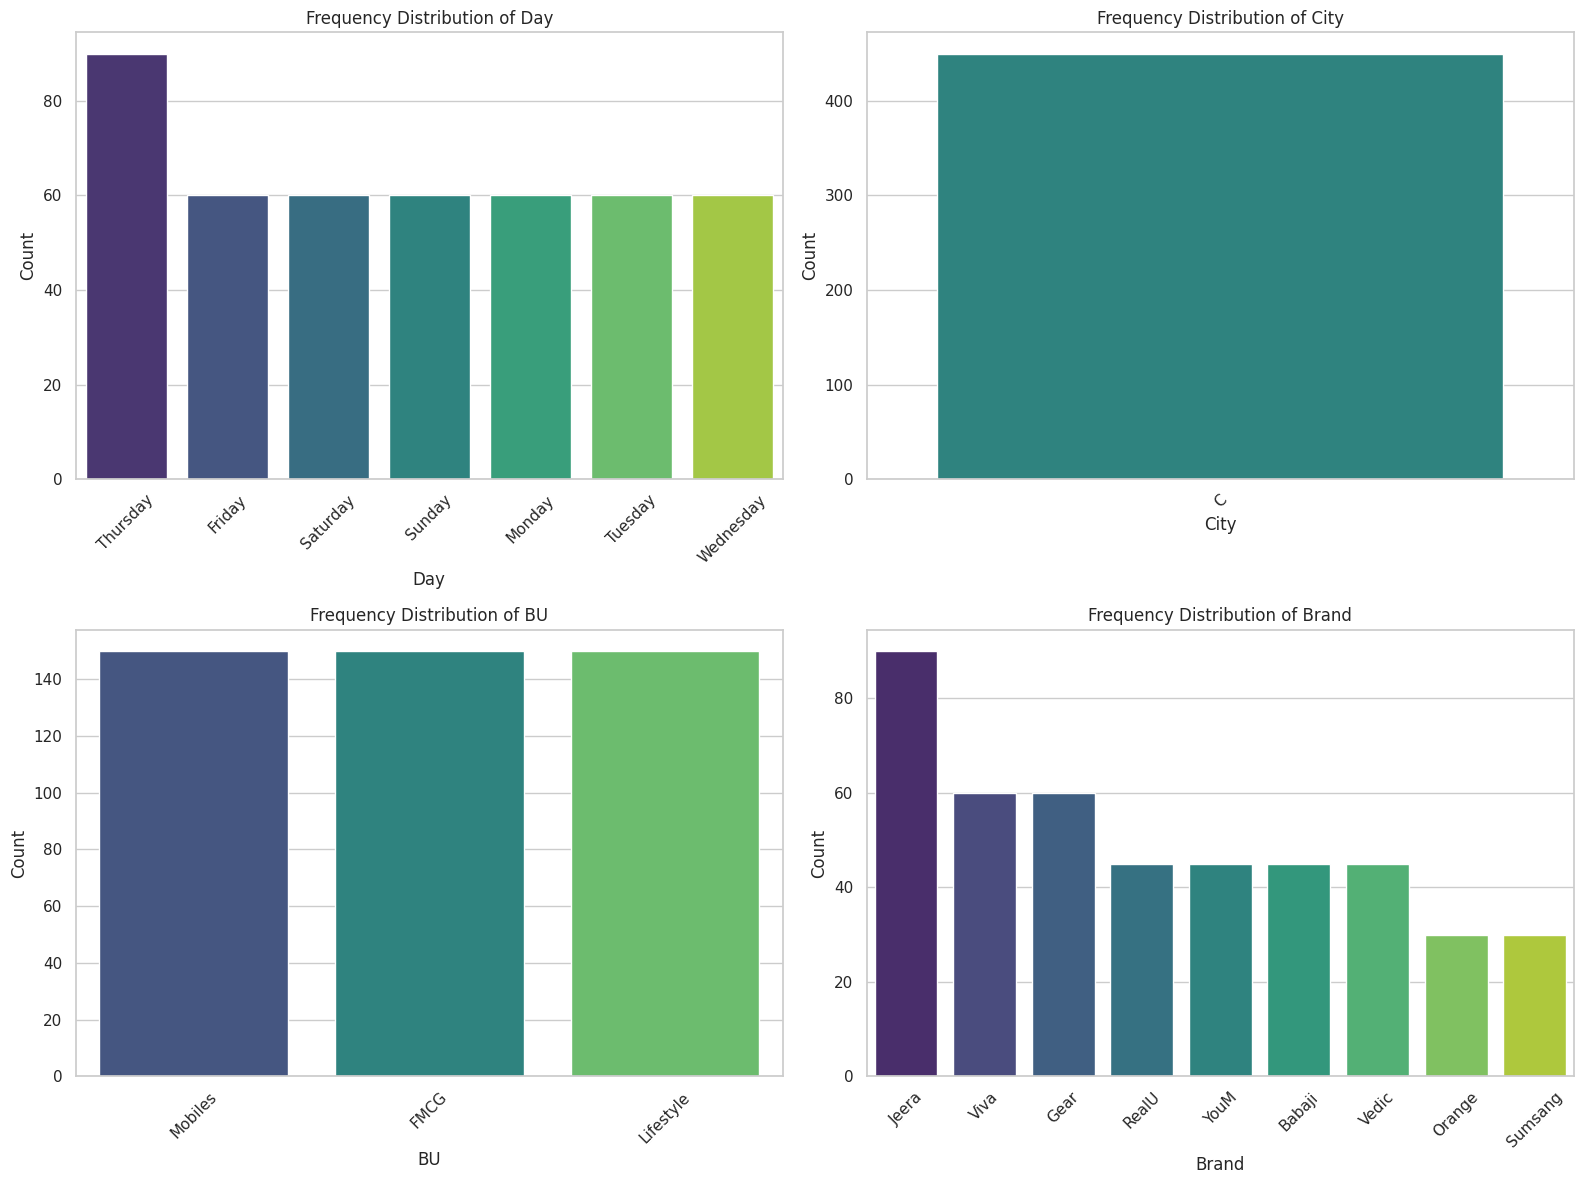

In [ ]:
# Identify categorical columns (excluding 'Date' and 'SKU' as they have too many unique values for a neat bar chart)
categorical_cols = ['Day', 'City', 'BU', 'Brand']

# Create bar charts
plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    # Count frequencies and sort
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')
    plt.title(f'Frequency Distribution of {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Bar Chart Inferences
* **Business Unit (BU):** The bar chart reveals the proportion of transactions across `Mobiles`, `FMCG`, and `Lifestyle`. This tells us that all the business unit drives the equal transaction volume.
* **Brands:** By plotting the `Brand` column, we can easily identify the top-selling brands by transaction count. We can observe the `Jeera` brand is having the highest transaction count.
* **Day & City:** These charts reveal temporal and geographical patterns, such as whether certain days of the week experience higher traffic or if specific cities dominate the sales volume.

# Conclusion

Through descriptive analytics and data visualization, several key insights regarding the sales and discounts dataset were uncovered:

1.  **Data Distributions:** The histograms and statistical measures (Mean > Median) indicate that the sales revenue and volume data are largely right-skewed. This is typical in retail, where standard purchases form the bulk of transactions, and premium purchases form a long tail.
2.  **Outlier Presence:** Box plot analysis confirmed the presence of high-value outliers in `Total Sales`, `Avg Price`, and `Net Sales Value`. These are likely driven by the `Mobiles` Business Unit, which commands higher price points compared to `FMCG`.
3.  **Categorical Dominance:** The bar charts successfully highlighted the best-performing Business Units and Brands by transaction count, providing a clear picture of the product mix.

These foundational insights validate the integrity of the data and provide clear directions for deeper, more predictive analytical modeling in the future.